# Single Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

import sys
sys.path.insert(1, '../../functions')
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def offline_opt(budget, size):
    # return [budget / np.sum(size) * size[i] for i in range(len(size))]
    return [budget / np.sum(size) for i in range(len(size))]

In [3]:
def hope_online(budget, size, mean):
    # initialize allocation vector
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
        # allocation[i] = budget_remaining * size[i] / (size[i] + np.sum(mean[i+1:]))
        allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]))
        
        
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [4]:
def hope_full(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
#         allocation[i] = min(budget_remaining, budget*size[i] / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))
        allocation[i] = min(budget_remaining / size[i], budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))

        budget_remaining -= allocation[i] * size[i]
    return allocation



In [5]:
def hope_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    thresh = budget / (size[0] + np.sum(mean[1:]) + np.sqrt(np.log(len(size)-1) * (len(size)-1)))

    for i in range(len(allocation)):
        # allocation[i] = min(budget_remaining, thresh * size[i])
        allocation[i] = min(budget_remaining / size[i], thresh)
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [6]:
def hope_modified(budget, size, mean):
   
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
        # allocation[i] = budget_remaining * size[i] / (size[i] + np.sum(mean[i+1:]))
        allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]) + 1.5*np.log(len(size)))
        # allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]) + np.sqrt(len(size)))
        budget_remaining -= allocation[i] * size[i]
    return allocation


### Test

In [7]:
n = 6
sorted_distribution = np.asarray([np.arange(2) + 1 for x in range(n)])
weights = np.asarray([np.zeros(2)+0.5 for x in range(n)])
mean = [np.dot(weights[i], sorted_distribution[i]) for i in range(n)]

expected_demand = 1.5
budget = n * expected_demand
print(budget)

9.0


In [8]:
print(weights)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [9]:
print(sorted_distribution)

[[1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]]


In [10]:
size = [2., 1., 1., 1., 2., 1.]

In [11]:
len(size)

6

In [12]:
print(offline_opt(budget, size))

[1.125, 1.125, 1.125, 1.125, 1.125, 1.125]


In [13]:
print(hope_online(budget, size, mean))

[0.94736842 1.01503759 1.10731374 1.24572796 1.06776682 1.60165023]


In [14]:
print(hope_full(budget, size, mean))

[0.94736842 1.         1.05882353 1.125      1.05882353 1.125     ]


In [15]:
print(hope_modified(budget, size, mean))

[0.7384531  0.77656626 0.82398935 0.88559475 0.81403315 0.92440636]


In [16]:
print(hope_threshold(budget, size, mean))

[0.72952722 0.72952722 0.72952722 0.72952722 0.72952722 0.72952722]


### Simulating scaling of $\Delta$

In [17]:
max_n = 100
num_iters = 1000


final_vec = []
for i in np.arange(1, max_n):
    budget = i
    size_one = [1.]
    dist = []
    med = [0., 0.]
    for _ in range(num_iters):
        sizes = np.random.choice(size=i-1, a=[1., 2.], p=[1/2, 1/2])
        # print(size_one, sizes)
        full_size = np.append(size_one[0], sizes)
        # print(len(full_size))
        # print('hi')
        dist.append(1 / np.sum(full_size))
    med[0] = np.median(dist)

    dist = []
    size_one = [2.]
    for _ in range(num_iters):
        sizes = np.random.choice(size=i-1, a=[1., 2.], p=[1/2, 1/2])
        # print(size_one, sizes)
        full_size = np.append(size_one[0], sizes)
        # print(len(full_size))
        # print('hi')
        dist.append(1 / np.sum(full_size))
    med[1] = np.median(dist)

    # print(med)

    dist = []
    for _ in range(num_iters):
        sizes = np.random.choice(size=i, a=[1., 2.], p=[1/2, 1/2])
        dist.append(np.abs( (budget*sizes[0] / np.sum(sizes)) - (budget*sizes[0]*med[int(sizes[0]-1)])))
    final_vec.append(np.mean(dist))

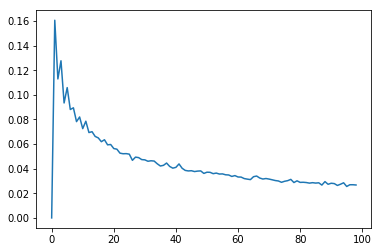

In [18]:
plt.plot(final_vec)

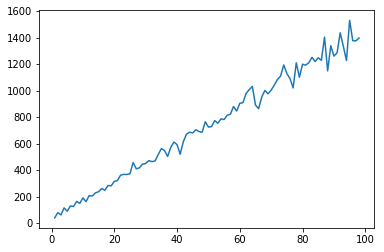

In [19]:
plt.plot([1/(final_vec[i]**2) for i in range(len(final_vec))])

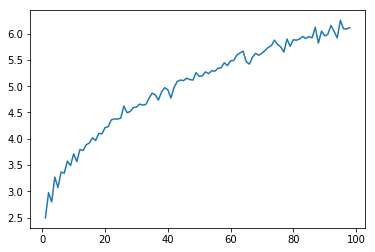

In [20]:
plt.plot([1/(final_vec[i]**(1/2)) for i in range(len(final_vec))])

### Scaling with n

In [21]:
data_dict = {'NumGroups':[], 'Norm':[], 'Hope_Online':[], 'Hope_Full':[], 'Hope_Modified':[], 'Hope_Threshold':[]}

num_iterations = 1000
max_n = 100

for n in np.arange(2,max_n+1):
    n = max(int(n),1)
    expected_size = np.zeros(n) + 1.5
    
    budget = n
    print(n)
    
    for i in range(num_iterations):
        
        data_dict['NumGroups'].append(n)
        
        size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
        opt = offline_opt(budget, size)
        hope_on = hope_online(budget, size, expected_size)
        hope_ful = hope_full(budget, size, expected_size)
        hope_mod = hope_modified(budget, size, expected_size)
        hope_thresh = hope_threshold(budget, size, expected_size)
     
        data_dict['Norm'].append('L1')
        data_dict['Hope_Online'].append(np.sum(np.absolute(opt - hope_on)))
        data_dict['Hope_Full'].append(np.sum(np.absolute(opt-hope_ful)))
        data_dict['Hope_Modified'].append(np.sum(np.absolute(opt-hope_mod)))
        data_dict['Hope_Threshold'].append(np.sum(np.absolute(opt-hope_thresh)))



        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Linf')
        data_dict['Hope_Online'].append(np.max(np.absolute(opt - hope_on)))
        data_dict['Hope_Full'].append(np.max(np.absolute(opt-hope_ful)))
        data_dict['Hope_Modified'].append(np.max(np.absolute(opt-hope_mod)))
        data_dict['Hope_Threshold'].append(np.max(np.absolute(opt-hope_thresh)))
        
        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Waste')
        data_dict['Hope_Online'].append(budget - np.dot(hope_on, size))
        data_dict['Hope_Full'].append(budget - np.dot(hope_ful,size))
        data_dict['Hope_Modified'].append(budget - np.dot(hope_mod, size))
        data_dict['Hope_Threshold'].append(budget - np.dot(hope_thresh, size))
        

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


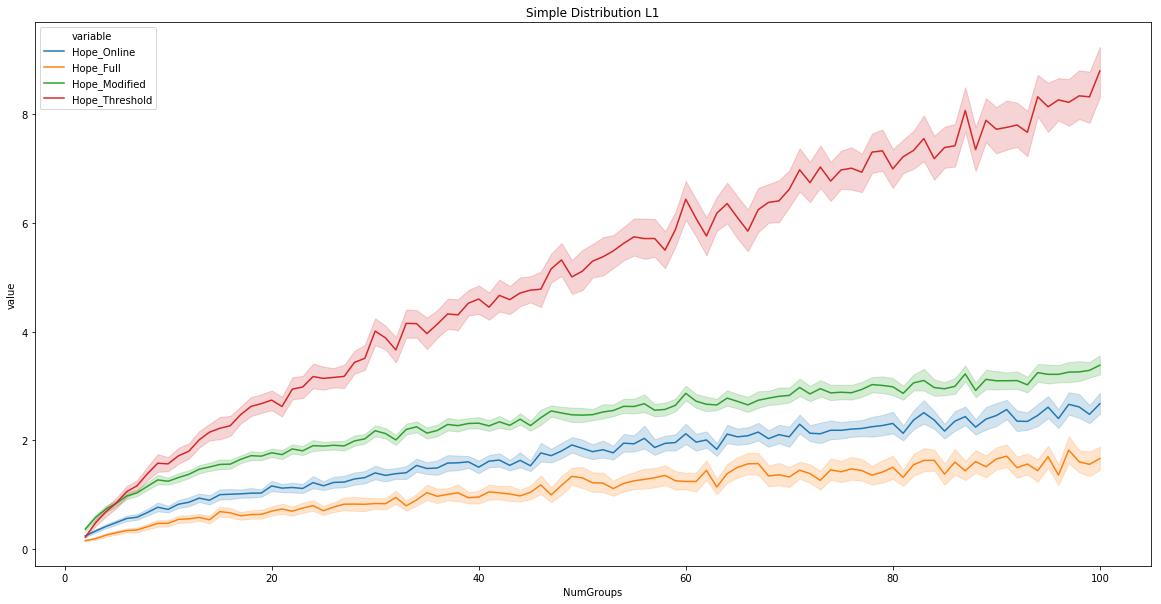

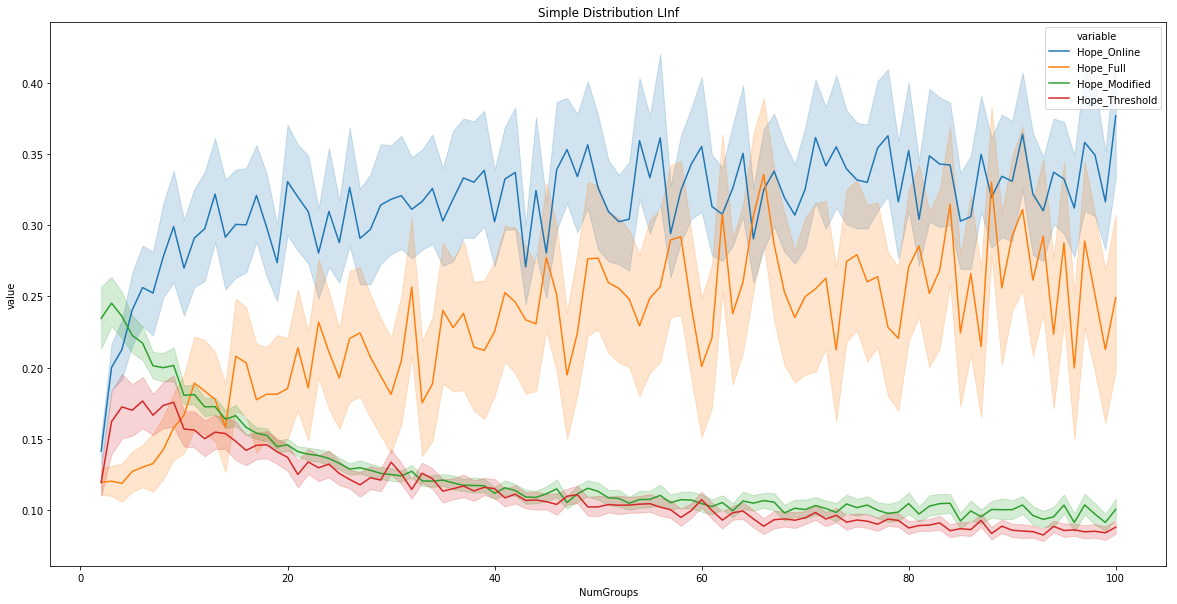

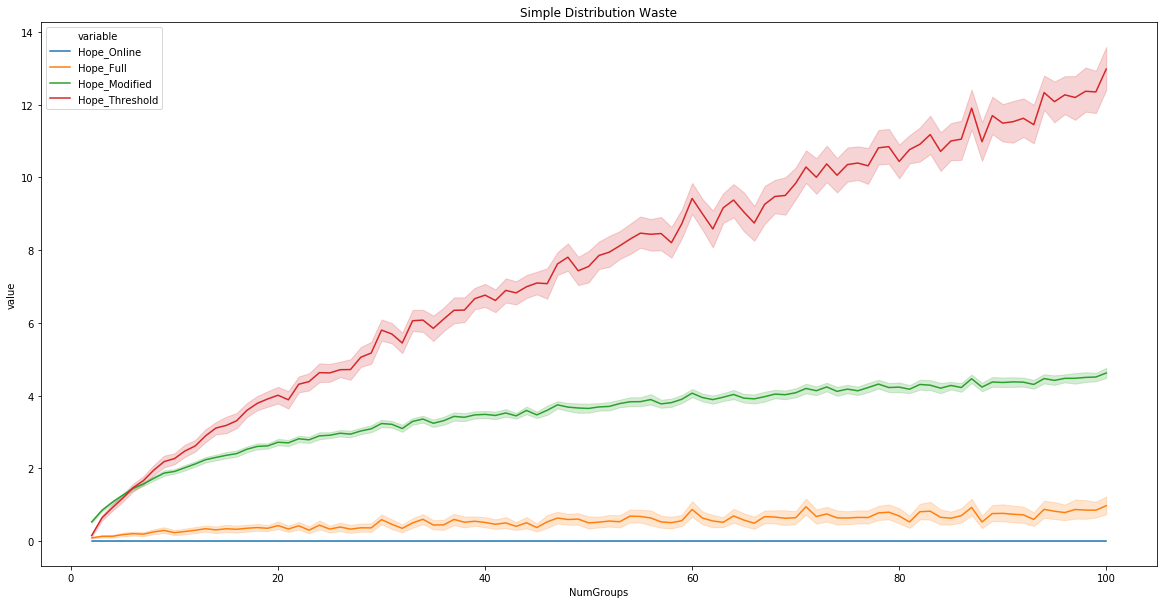

In [22]:
df = pd.DataFrame(data_dict).melt(id_vars=["NumGroups", 'Norm'])
df.to_csv('scale_with_n.csv')
df.columns


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Simple Distribution L1')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Linf'])


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Waste'])


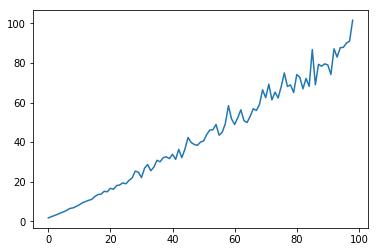

In [29]:
algo = 'Hope_Modified'
metric = 'Waste'

data = df[(df.Norm == metric) & (df.variable == algo)]
avg = data.groupby(['NumGroups']).mean().to_numpy()
# print(avg)
# plt.plot([avg[i]**2 for i in range(len(avg))])
plt.plot([np.exp(avg[i]) for i in range(len(avg))])

### Group by Group Difference

In [24]:
n = 50
num_iterations = 1000

expected_size = 1.5
group = np.arange(n)
budget = expected_size*n
group = np.arange(n)


score_hope_online = np.zeros((n,num_iterations))
score_hope_full = np.zeros((n,num_iterations))
score_hope_modified = np.zeros((n, num_iterations))
score_hope_threshold = np.zeros((n, num_iterations))


for i in range(num_iterations):
    group_sizes = np.random.choice(size=n, a=[1., 2.], p=[1/2, 1/2])
    
   
    expected_size = np.zeros(n) + 1.5
 
    
    size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    opt = offline_opt(budget, size)
    hope_on = hope_online(budget, size, expected_size)
    hope_ful = hope_full(budget, size, expected_size)
    hope_mod = hope_modified(budget, size, expected_size)
    hope_thresh = hope_threshold(budget, size, expected_size)
    
    # comparing hope_online
    
    score_hope_online[:,i] = opt - hope_on
    score_hope_full[:,i] = opt-hope_ful
    score_hope_modified[:,i] = opt-hope_mod
    score_hope_threshold[:,i] = opt - hope_thresh

Text(0.5,0,'Value')

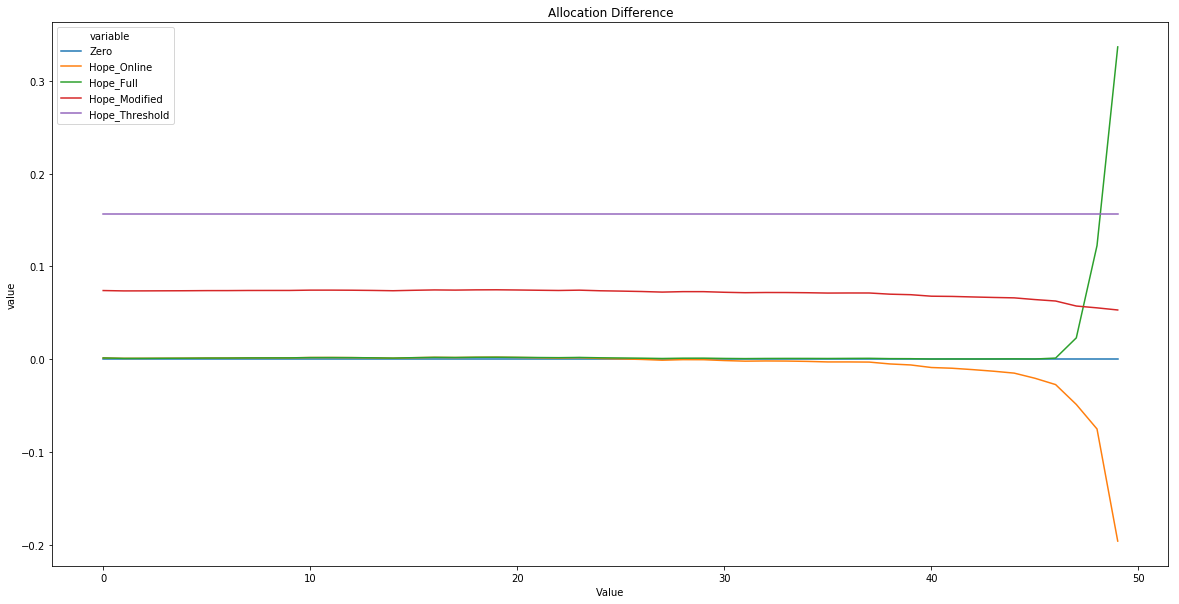

In [25]:
data_dict = {'Agent':group, 'Zero': np.zeros(n), 'Hope_Online': np.average(score_hope_online, axis=1), 'Hope_Full':np.average(score_hope_full, axis=1), 'Hope_Modified':np.average(score_hope_modified, axis=1), 'Hope_Threshold':np.average(score_hope_threshold, axis=1)}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Agent")

plt.figure(figsize=(20,10))
sns.lineplot(x='Agent', y='value', hue = 'variable', data=df_uniform)
plt.title('Allocation Difference')
plt.xlabel('Value')